

## 1. Business Understanding

Kualitas udara merupakan salah satu aspek penting dalam pengamatan kondisi lingkungan. Data penginderaan jauh dapat digunakan untuk memperoleh informasi mengenai berbagai parameter atmosfer.

Pada analisis ini digunakan data dari **Copernicus Data Space Ecosystem**. Wilayah pengamatan difokuskan pada **Klampis, Kabupaten Bangkalan, Jawa Timur**.

Parameter yang digunakan adalah:

- Carbon Monoxide (CO)
- Nitrogen Dioxide (NO₂)
- Sulfur Dioxide (SO₂)
- Methane (CH₄)

Data digunakan untuk melihat karakteristik dan perubahan nilai parameter atmosfer berdasarkan waktu.

## 2. Data Understanding

Data diperoleh melalui **Copernicus Browser**

Area pengamatan ditentukan menggunakan **Area of Interest (AOI)** pada wilayah Klampis, Kabupaten Bangkalan.

Data hasil pengamatan diekspor dalam format CSV melalui fitur **Time Series**.

Setiap file hasil ekspor memiliki beberapa informasi statistik:

- `date` → tanggal pengamatan
- `min` → nilai minimum
- `max` → nilai maksimum
- `mean` → nilai rata-rata
- `stDev` → standar deviasi
- `sampleCount` → jumlah sampel
- `noDataCount` → jumlah data yang tidak tersedia
- `median` → median
- `p10` → persentil 10%
- `p90` → persentil 90%

Jumlah observasi setiap parameter dapat berbeda karena ketersediaan data satelit tidak selalu sama pada setiap tanggal.

In [1]:
import io
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

try:
    from google.colab import files
except ModuleNotFoundError:
    files = None

if files is not None:
    print("Upload 4 file CSV dari Copernicus:")
    print("CO, NO2, SO2, dan CH4")
    uploaded = files.upload()
else:
    search_roots = [Path.cwd(), Path.cwd().parent]
    csv_paths = []
    for root in search_roots:
        csv_paths.extend(root.glob("Sentinel-5P_*.csv"))
    csv_paths = sorted(set(csv_paths))
    uploaded = {path.name: path.read_bytes() for path in csv_paths}
    print(f"Mode lokal: {len(uploaded)} file CSV ditemukan.")

data = {}

for filename, content in uploaded.items():

    nama = filename.upper()

    if "SENTINEL-5P_CO" in nama:
        polutan = "CO"

    elif "SENTINEL-5P_NO2" in nama:
        polutan = "NO2"

    elif "SENTINEL-5P_SO2" in nama:
        polutan = "SO2"

    elif "SENTINEL-5P_CH4" in nama:
        polutan = "CH4"

    else:
        print(f"File dilewati: {filename}")
        continue

    df = pd.read_csv(io.BytesIO(content))

    # Bersihkan nama kolom
    df.columns = df.columns.str.strip()

    # Pastikan tanggal terbaca
    df["C0/date"] = pd.to_datetime(
        df["C0/date"],
        errors="coerce",
        utc=True
    )

    # Hilangkan timezone
    df["C0/date"] = df["C0/date"].dt.tz_localize(None)

    # Hapus tanggal yang tidak valid
    df = df.dropna(subset=["C0/date"])

    # Urutkan berdasarkan tanggal
    df = df.sort_values("C0/date").reset_index(drop=True)

    data[polutan] = df

    print("\n" + "=" * 60)
    print(f"Parameter : {polutan}")
    print(f"File      : {filename}")
    print(f"Jumlah baris : {len(df)}")
    print(f"Periode     : {df['C0/date'].min()} sampai {df['C0/date'].max()}")

Mode lokal: 4 file CSV ditemukan.

Parameter : CH4
File      : Sentinel-5P_CH4-CH4_VISUALIZED-2025-08-31T00_00_00_000Z-2026-08-31T23_59_59_999Z.csv
Jumlah baris : 14
Periode     : 2025-09-23 00:00:00 sampai 2026-08-26 00:00:00

Parameter : CO
File      : Sentinel-5P_CO-Custom-2025-01-28T00_00_00_000Z-2026-01-28T23_59_59_999Z.csv
Jumlah baris : 184
Periode     : 2025-01-29 00:00:00 sampai 2026-01-26 00:00:00

Parameter : NO2
File      : Sentinel-5P_NO2-NO2_VISUALIZED-2025-01-28T00_00_00_000Z-2026-01-28T23_59_59_999Z.csv
Jumlah baris : 176
Periode     : 2025-02-01 00:00:00 sampai 2026-01-26 00:00:00

Parameter : SO2
File      : Sentinel-5P_SO2-SO2_VISUALIZED-2026-02-10T00_00_00_000Z-2026-08-10T23_59_59_999Z.csv
Jumlah baris : 125
Periode     : 2026-02-12 00:00:00 sampai 2026-08-10 00:00:00


## 3. Pemeriksaan Data

Pemeriksaan dilakukan untuk mengetahui jumlah observasi, periode pengamatan, struktur kolom, dan kondisi data dari masing-masing parameter.

In [2]:
for polutan, df in data.items():

    print("\n" + "=" * 60)
    print(polutan)
    print("=" * 60)

    print("Jumlah baris :", len(df))
    print("Jumlah kolom :", len(df.columns))

    print("\nKolom:")
    print(list(df.columns))

    print("\nPeriode:")
    print("Awal  :", df["C0/date"].min())
    print("Akhir :", df["C0/date"].max())

    print("\nMissing value:")
    print(df.isna().sum())

    print("\n5 data pertama:")
    display(df.head())


CH4
Jumlah baris : 14
Jumlah kolom : 10

Kolom:
['C0/date', 'C0/min', 'C0/max', 'C0/mean', 'C0/stDev', 'C0/sampleCount', 'C0/noDataCount', 'C0/median', 'C0/p10', 'C0/p90']

Periode:
Awal  : 2025-09-23 00:00:00
Akhir : 2026-08-26 00:00:00

Missing value:
C0/date           0
C0/min            0
C0/max            0
C0/mean           0
C0/stDev          0
C0/sampleCount    0
C0/noDataCount    0
C0/median         0
C0/p10            0
C0/p90            0
dtype: int64

5 data pertama:


,C0/date,C0/min,C0/max,C0/mean,C0/stDev,C0/sampleCount,C0/noDataCount,C0/median,C0/p10,C0/p90
0,2025-09-23,1880.062134,1880.062134,1880.062134,0.000000,6,0,1880.062134,1880.062134,1880.062134
1,2026-01-30,1942.427246,1957.402832,1949.463460,5.394262,6,0,1951.507812,1942.427246,1957.402832
2,2026-04-20,1864.500122,1864.500122,1864.500122,0.000000,6,5,1864.500122,1864.500122,1864.500122
3,2026-06-02,1900.692871,1900.692871,1900.692871,0.000000,6,4,1900.692871,1900.692871,1900.692871
4,2026-06-07,1868.984253,1868.984253,1868.984253,0.000000,6,2,1868.984253,1868.984253,1868.984253



CO
Jumlah baris : 184
Jumlah kolom : 10

Kolom:
['C0/date', 'C0/min', 'C0/max', 'C0/mean', 'C0/stDev', 'C0/sampleCount', 'C0/noDataCount', 'C0/median', 'C0/p10', 'C0/p90']

Periode:
Awal  : 2025-01-29 00:00:00
Akhir : 2026-01-26 00:00:00

Missing value:
C0/date             0
C0/min              0
C0/max              0
C0/mean             0
C0/stDev            0
C0/sampleCount      0
C0/noDataCount      0
C0/median         184
C0/p10            184
C0/p90            184
dtype: int64

5 data pertama:


,C0/date,C0/min,C0/max,C0/mean,C0/stDev,C0/sampleCount,C0/noDataCount,C0/median,C0/p10,C0/p90
0,2025-01-29,0.026266,0.026266,0.026266,0.000000,6,4,NaN,NaN,NaN
1,2025-02-02,0.028865,0.028865,0.028865,0.000000,6,5,NaN,NaN,NaN
2,2025-02-04,0.029160,0.029160,0.029160,0.000000,6,4,NaN,NaN,NaN
3,2025-02-05,0.024384,0.036447,0.027979,0.005106,6,0,NaN,NaN,NaN
4,2025-02-06,0.031698,0.031809,0.031754,0.000055,6,0,NaN,NaN,NaN



NO2
Jumlah baris : 176
Jumlah kolom : 10

Kolom:
['C0/date', 'C0/min', 'C0/max', 'C0/mean', 'C0/stDev', 'C0/sampleCount', 'C0/noDataCount', 'C0/median', 'C0/p10', 'C0/p90']

Periode:
Awal  : 2025-02-01 00:00:00
Akhir : 2026-01-26 00:00:00

Missing value:
C0/date           0
C0/min            0
C0/max            0
C0/mean           0
C0/stDev          0
C0/sampleCount    0
C0/noDataCount    0
C0/median         0
C0/p10            0
C0/p90            0
dtype: int64

5 data pertama:


,C0/date,C0/min,C0/max,C0/mean,C0/stDev,C0/sampleCount,C0/noDataCount,C0/median,C0/p10,C0/p90
0,2025-02-01,0.000009,0.000019,0.000017,0.000005,6,2,0.000019,0.000019,0.000019
1,2025-02-03,0.000003,0.000003,0.000003,0.000000,6,3,0.000003,0.000003,0.000003
2,2025-02-04,0.000016,0.000016,0.000016,0.000000,6,5,0.000016,0.000016,0.000016
3,2025-02-05,0.000013,0.000028,0.000019,0.000005,6,0,0.000020,0.000013,0.000028
4,2025-02-06,0.000013,0.000020,0.000018,0.000003,6,0,0.000020,0.000013,0.000020



SO2
Jumlah baris : 125
Jumlah kolom : 10

Kolom:
['C0/date', 'C0/min', 'C0/max', 'C0/mean', 'C0/stDev', 'C0/sampleCount', 'C0/noDataCount', 'C0/median', 'C0/p10', 'C0/p90']

Periode:
Awal  : 2026-02-12 00:00:00
Akhir : 2026-08-10 00:00:00

Missing value:
C0/date           0
C0/min            0
C0/max            0
C0/mean           0
C0/stDev          0
C0/sampleCount    0
C0/noDataCount    0
C0/median         0
C0/p10            0
C0/p90            0
dtype: int64

5 data pertama:


,C0/date,C0/min,C0/max,C0/mean,C0/stDev,C0/sampleCount,C0/noDataCount,C0/median,C0/p10,C0/p90
0,2026-02-12,-0.000272,-0.000105,-0.000172,0.000082,6,1,-0.000105,-0.000272,-0.000105
1,2026-02-15,-0.000404,0.000059,-0.000111,0.000181,6,0,0.000059,-0.000220,0.000059
2,2026-02-16,0.000245,0.000245,0.000245,0.000000,6,5,0.000245,0.000245,0.000245
3,2026-02-18,-0.000203,-0.000203,-0.000203,0.000000,6,5,-0.000203,-0.000203,-0.000203
4,2026-02-20,-0.000115,0.000088,-0.000029,0.000086,6,0,-0.000059,-0.000115,0.000088


## 4. Penyederhanaan Data

Untuk visualisasi, digunakan nilai `mean` sebagai nilai utama setiap parameter pada setiap tanggal pengamatan.

Kolom `C0/mean` akan digunakan sebagai nilai rata-rata hasil pengamatan pada AOI.

Data lain seperti minimum, maximum, standard deviation, median, p10, dan p90 tetap tersedia pada data asli.

In [3]:
# Membuat data sederhana untuk visualisasi

data_plot = {}

for polutan, df in data.items():

    temp = df[["C0/date", "C0/mean"]].copy()

    temp.columns = ["date", polutan]

    data_plot[polutan] = temp

    print(f"{polutan}: {len(temp)} observasi")

CH4: 14 observasi
CO: 184 observasi
NO2: 176 observasi
SO2: 125 observasi


## 5. Visualisasi Carbon Monoxide (CO)

Grafik berikut menunjukkan perubahan nilai rata-rata Carbon Monoxide (CO) berdasarkan tanggal pengamatan pada wilayah penelitian.

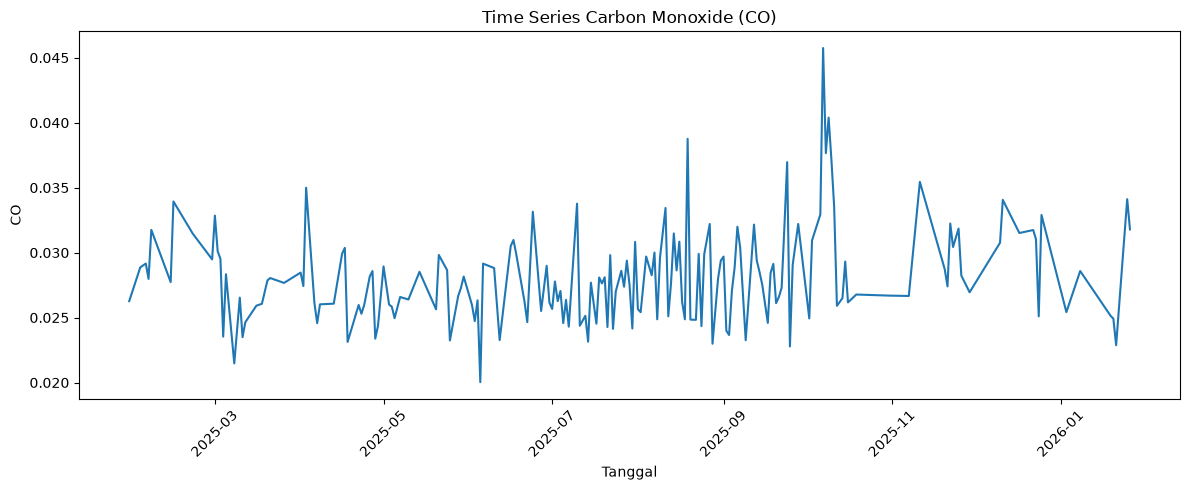

In [4]:
if "CO" in data_plot:

    df_co = data_plot["CO"]

    plt.figure(figsize=(12, 5))
    plt.plot(df_co["date"], df_co["CO"])
    plt.xlabel("Tanggal")
    plt.ylabel("CO")
    plt.title("Time Series Carbon Monoxide (CO)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

else:
    print("Data CO belum tersedia.")

### Interpretasi CO

Grafik digunakan untuk melihat perubahan nilai CO sepanjang periode pengamatan.

Perubahan naik dan turun pada grafik menunjukkan adanya variasi nilai CO pada tanggal pengamatan yang tersedia. Karena data Sentinel-5P tidak selalu memiliki observasi valid pada setiap tanggal, jumlah titik pada grafik tidak harus sama dengan jumlah hari dalam satu tahun.

## 6. Visualisasi Nitrogen Dioxide (NO₂)

Grafik berikut menunjukkan perubahan nilai rata-rata Nitrogen Dioxide (NO₂) berdasarkan waktu.

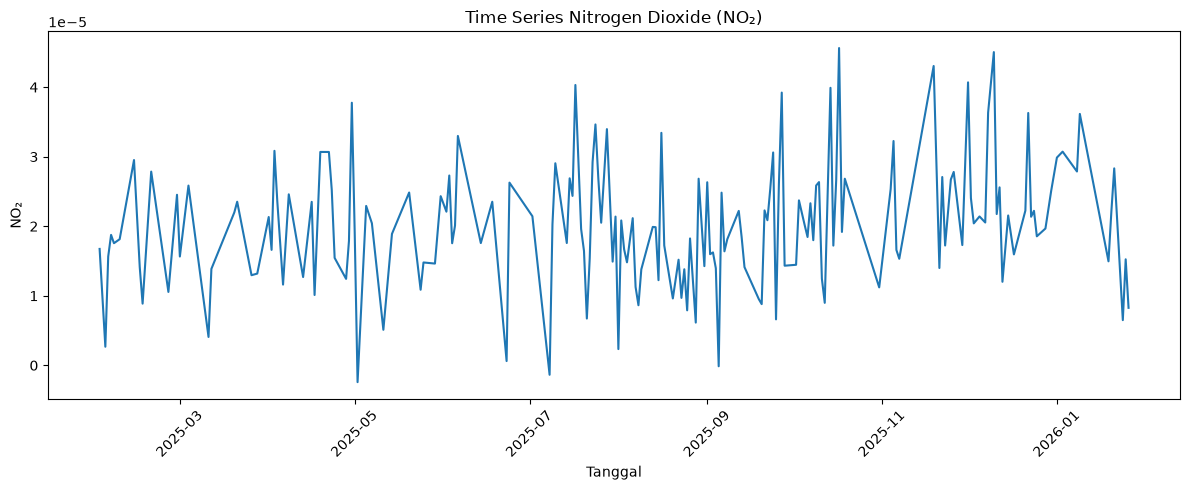

In [5]:
if "NO2" in data_plot:

    df_no2 = data_plot["NO2"]

    plt.figure(figsize=(12, 5))
    plt.plot(df_no2["date"], df_no2["NO2"])
    plt.xlabel("Tanggal")
    plt.ylabel("NO₂")
    plt.title("Time Series Nitrogen Dioxide (NO₂)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

else:
    print("Data NO₂ belum tersedia.")

### Interpretasi NO₂

Grafik menunjukkan perubahan nilai rata-rata NO₂ pada tanggal pengamatan yang tersedia.

Perbedaan nilai dari waktu ke waktu menunjukkan adanya variasi konsentrasi NO₂ pada wilayah AOI penelitian.

## 7. Visualisasi Sulfur Dioxide (SO₂)

Grafik berikut menunjukkan perubahan nilai rata-rata Sulfur Dioxide (SO₂) berdasarkan waktu.

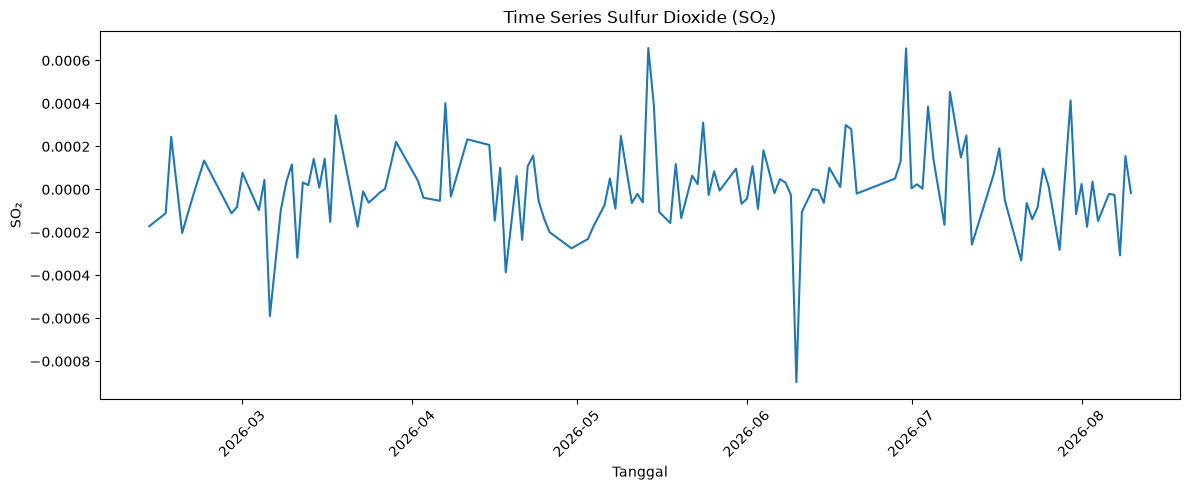

In [6]:
if "SO2" in data_plot:

    df_so2 = data_plot["SO2"]

    plt.figure(figsize=(12, 5))
    plt.plot(df_so2["date"], df_so2["SO2"])
    plt.xlabel("Tanggal")
    plt.ylabel("SO₂")
    plt.title("Time Series Sulfur Dioxide (SO₂)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

else:
    print("Data SO₂ belum tersedia.")

### Interpretasi SO₂

Grafik digunakan untuk melihat perubahan nilai SO₂ berdasarkan waktu pada wilayah penelitian.

Jumlah titik pengamatan bergantung pada ketersediaan data Sentinel-5P pada AOI dan periode yang digunakan.

## 8. Visualisasi Methane (CH₄)

Grafik berikut menunjukkan nilai rata-rata Methane (CH₄) berdasarkan tanggal pengamatan.

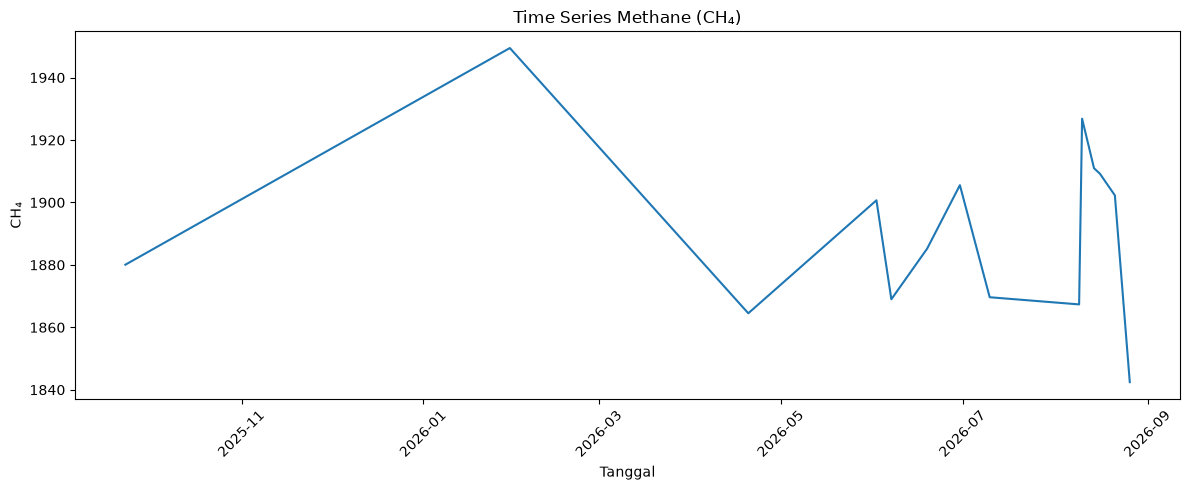

In [7]:
if "CH4" in data_plot:

    df_ch4 = data_plot["CH4"]

    plt.figure(figsize=(12, 5))
    plt.plot(df_ch4["date"], df_ch4["CH4"])
    plt.xlabel("Tanggal")
    plt.ylabel("CH₄")
    plt.title("Time Series Methane (CH₄)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

else:
    print("Data CH₄ belum tersedia.")

### Interpretasi CH₄

Grafik menunjukkan perubahan nilai rata-rata CH₄ berdasarkan pengamatan yang tersedia.

Jumlah observasi CH₄ dapat lebih sedikit dibandingkan parameter lain karena ketersediaan data pengamatan pada wilayah dan periode tertentu.

## 9. Statistik Deskriptif

Statistik deskriptif digunakan untuk mengetahui karakteristik dasar dari masing-masing parameter.

Statistik yang digunakan meliputi:

- jumlah data
- minimum
- maksimum
- mean
- median
- standard deviation
- skewness
- kurtosis

In [8]:
# Membuat tabel statistik setiap parameter

statistik = []

for polutan, df in data.items():

    nilai = pd.to_numeric(
        df["C0/mean"],
        errors="coerce"
    ).dropna()

    if len(nilai) == 0:
        continue

    statistik.append({
        "Parameter": polutan,
        "Jumlah Data": len(nilai),
        "Minimum": nilai.min(),
        "Maximum": nilai.max(),
        "Mean": nilai.mean(),
        "Median": nilai.median(),
        "Std. Deviasi": nilai.std(),
        "Skewness": nilai.skew(),
        "Kurtosis": nilai.kurtosis()
    })

tabel_statistik = pd.DataFrame(statistik)

display(tabel_statistik.round(6))

,Parameter,Jumlah Data,Minimum,Maximum,Mean,Median,Std. Deviasi,Skewness,Kurtosis
0,CH4,14,1842.441406,1949.463460,1891.649809,1892.942322,28.516716,0.295352,-0.090167
1,CO,184,0.020033,0.045747,0.028099,0.027672,0.003625,1.219571,3.131961
2,NO2,176,-0.000002,0.000046,0.000020,0.000020,0.000009,0.266052,0.435514
3,SO2,125,-0.000897,0.000658,0.000008,-0.000004,0.000206,-0.192415,3.664972


## 10. Pemeriksaan Missing Value

Missing value diperiksa untuk mengetahui jumlah tanggal yang tidak memiliki nilai pengamatan pada masing-masing parameter.

In [9]:
missing_data = []

for polutan, df in data.items():

    nilai = pd.to_numeric(
        df["C0/mean"],
        errors="coerce"
    )

    missing_data.append({
        "Parameter": polutan,
        "Jumlah Data": len(nilai),
        "Data Tersedia": nilai.notna().sum(),
        "Missing": nilai.isna().sum()
    })

tabel_missing = pd.DataFrame(missing_data)

display(tabel_missing)

,Parameter,Jumlah Data,Data Tersedia,Missing
0,CH4,14,14,0
1,CO,184,184,0
2,NO2,176,176,0
3,SO2,125,125,0


## 11. Perbandingan Nilai Rata-rata

Perbandingan berikut digunakan untuk melihat nilai rata-rata dari setiap parameter berdasarkan data yang tersedia.

,Parameter,Mean
0,CH4,1891.649809
1,CO,0.028099
2,NO2,0.000020
3,SO2,0.000008


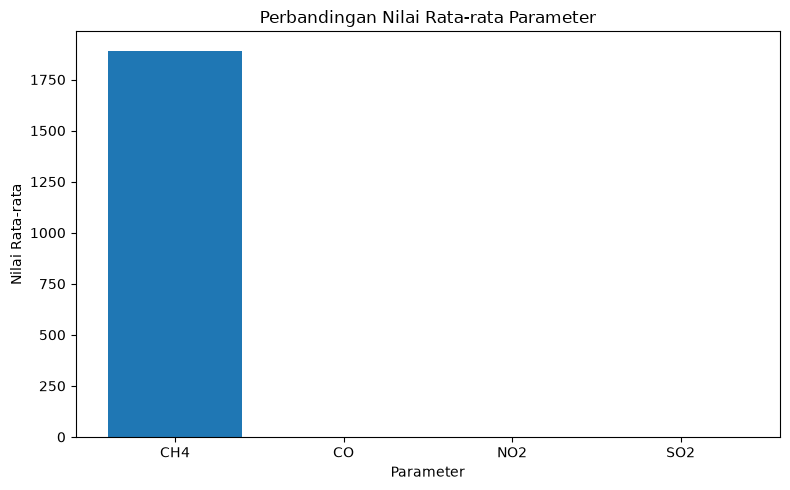

In [10]:
mean_data = []

for polutan, df in data.items():

    nilai = pd.to_numeric(
        df["C0/mean"],
        errors="coerce"
    ).dropna()

    if len(nilai) > 0:
        mean_data.append({
            "Parameter": polutan,
            "Mean": nilai.mean()
        })

df_mean = pd.DataFrame(mean_data)

display(df_mean.round(6))

plt.figure(figsize=(8, 5))
plt.bar(df_mean["Parameter"], df_mean["Mean"])
plt.xlabel("Parameter")
plt.ylabel("Nilai Rata-rata")
plt.title("Perbandingan Nilai Rata-rata Parameter")
plt.tight_layout()
plt.show()

## 12. Kesimpulan

Berdasarkan pengolahan data Copernicus Sentinel-5P pada wilayah Klampis, Kabupaten Bangkalan, diperoleh data untuk empat parameter atmosfer, yaitu Carbon Monoxide (CO), Nitrogen Dioxide (NO₂), Sulfur Dioxide (SO₂), dan Methane (CH₄).

Data setiap parameter memiliki jumlah observasi yang berbeda karena ketersediaan pengamatan satelit pada wilayah dan waktu tertentu tidak selalu sama.

Visualisasi time series digunakan untuk melihat perubahan nilai setiap parameter berdasarkan waktu, sedangkan statistik deskriptif digunakan untuk mengetahui karakteristik data seperti minimum, maksimum, mean, median, standard deviation, skewness, dan kurtosis.

Hasil pengolahan ini memberikan gambaran awal mengenai variasi parameter atmosfer di wilayah penelitian dan dapat digunakan sebagai dasar untuk analisis lebih lanjut.

In [11]:
import folium
from IPython.display import display

# ============================================================
# 1. GEOJSON AOI KLAMPIS
# ============================================================

aoi = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {
                "nama": "AOI Klampis",
                "wilayah": "Klampis",
                "kabupaten": "Bangkalan",
                "provinsi": "Jawa Timur"
            },
            "geometry": {
                "type": "Polygon",
                "coordinates": [[
                    [112.878389, -6.890926],
                    [112.878389, -6.950537],
                    [112.953048, -6.950537],
                    [112.953048, -6.890926],
                    [112.878389, -6.890926]
                ]]
            }
        }
    ]
}

# ============================================================
# 2. TITIK TENGAH AOI
# ============================================================

latitude = -6.9207315
longitude = 112.9157185

# ============================================================
# 3. MEMBUAT PETA
# ============================================================

peta = folium.Map(
    location=[latitude, longitude],
    zoom_start=12,
    tiles="OpenStreetMap"
)

# ============================================================
# 4. MENAMPILKAN AOI
# ============================================================

folium.GeoJson(
    aoi,
    name="Area of Interest (AOI) Klampis",
    style_function=lambda feature: {
        "fillColor": "#ff7800",
        "color": "#e65100",
        "weight": 2.5,
        "fillOpacity": 0.30,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[
            "nama",
            "wilayah",
            "kabupaten",
            "provinsi"
        ],
        aliases=[
            "Nama:",
            "Wilayah:",
            "Kabupaten:",
            "Provinsi:"
        ]
    )
).add_to(peta)

# ============================================================
# 5. MARKER
# ============================================================

folium.Marker(
    location=[latitude, longitude],
    popup="Wilayah Klampis, Kabupaten Bangkalan, Jawa Timur",
    tooltip="Klampis"
).add_to(peta)

# ============================================================
# 6. LAYER CONTROL
# ============================================================

folium.LayerControl().add_to(peta)

# ============================================================
# 7. TAMPILKAN PETA
# ============================================================

display(peta)